# 🎓 EduTech Academy AI Agent
### *Asistente Inteligente Conversacional Multicanal (LangGraph + RAG + Text-to-SQL)*

---

[![OCI Deploy Status](https://img.shields.io/badge/Deploy-Oracle%20Cloud%20Infrastructure%20(OCI)-orange?style=for-the-badge&logo=oracle)](http://140.84.166.161/)
[![Python Version](https://img.shields.io/badge/Python-3.10%2B-blue?style=for-the-badge&logo=python)](https://www.python.org/)
[![LangGraph](https://img.shields.io/badge/Orchestrator-LangGraph-darkgreen?style=for-the-badge)](https://langchain-ai.github.io/langgraph/)
[![Google Gemini](https://img.shields.io/badge/LLM-Google%20Gemini%20%2F%20Gemma-blueviolet?style=for-the-badge&logo=googlegemini)](https://deepmind.google/technologies/gemini/)

Este repositorio contiene la implementación del **Agente Inteligente de EduTech Academy**, desarrollado para el **Challenge Alura Agente**. Es una solución robusta basada en inteligencia artificial capaz de resolver de forma interactiva consultas de alumnos sobre la academia. 

El agente utiliza un flujo conversacional inteligente que combina **Recuperación Generativa de Información (RAG)** a partir de documentos no estructurados con consultas estructuradas en tiempo real a una base de datos mediante **Text-to-SQL**, decidiendo de forma autónoma la mejor ruta para responder a cada consulta o solicitando aclaraciones adicionales cuando sea necesario.

---

## ☁️ Enlace de Prueba y Evidencia de Despliegue (OCI)

El agente ha sido desplegado exitosamente en la nube utilizando **Oracle Cloud Infrastructure (OCI)**. Está disponible de forma pública para pruebas en el siguiente enlace:

👉 **[http://140.84.166.161/](http://140.84.166.161/)**

### Detalles del Despliegue en OCI:
- **Infraestructura**: Instancia VM Compute de OCI (`VM.Standard.E4.Flex` u `Always Free`).
- **Sistema Operativo**: Ubuntu Server / Oracle Linux.
- **Servidor Web / Proxy**: Configuración de red para exponer el puerto por defecto de Streamlit (`8501`) mapeado al puerto estándar `80` mediante redirección de puerto o reglas de seguridad (Security List de la VCN en OCI) para facilitar el acceso sin puertos adicionales en la URL.
- **Persistencia**: Ejecución en segundo plano mediante un administrador de procesos (`systemd` o `screen`) que garantiza la alta disponibilidad del servicio ante desconexiones.

---

## 📄 Descripción General del Proyecto

EduTech Academy maneja dos grandes dominios de información:
1. **Información No Estructurada (Políticas y Documentación)**: Manuales de uso, reglamento del estudiante, políticas de becas, términos de servicio y preguntas frecuentes (FAQ).
2. **Información Estructurada (Datos Académicos y Administrativos)**: Catálogo de cursos activos, precios, duraciones, profesores asignados, cupos disponibles en tiempo real, registro de estudiantes inscritos, su progreso académico e historial de certificados emitidos.

El **Agente Inteligente** funciona como un punto de acceso unificado que:
- **Clasifica** en milisegundos la intención de la pregunta del usuario.
- **Consulta de forma dinámica** la base documental indexada (vía FAISS y Gemini Embeddings) o la base de datos SQL (vía generación, validación y ejecución de consultas en SQLite).
- **Ejecuta tareas híbridas** mediante un agente React autónomo cuando la respuesta requiere consolidar ambas fuentes.
- **Mantiene memoria a corto plazo** por cada hilo de conversación (`thread_id`), permitiendo interacciones fluidas de seguimiento.
- **Pausa su ejecución (Interrupts)** cuando el usuario envía una pregunta incompleta, esperando que este complete la aclaración antes de continuar con la resolución lógica.

---

## 📐 Arquitectura de la Solución

La solución está construida sobre un **Grafo de Estados Dirigido y Cíclico** implementado con **LangGraph**. A diferencia de los pipelines lineales tradicionales, LangGraph permite manejar ciclos lógicos y estados pausados por intervención del usuario (*Human-in-the-Loop*) de forma nativa.

### Diagrama del Flujo del Grafo

```mermaid
graph TD
    START([Inicio de Consulta]) --> decision[Nodo de Decisión / Triaje]
    
    decision -.->|arista_decision_triaje: 'rag'| rag_node[Nodo RAG<br>Recupera de FAISS y responde]
    decision -.->|arista_decision_triaje: 'sql'| sql_node[Nodo SQL<br>Genera, valida y ejecuta SQLite]
    decision -.->|arista_decision_triaje: 'hybrid'| hybrid_node[Nodo Híbrido<br>Agente reactivo con herramientas]
    decision -.->|arista_decision_triaje: 'ask_info'| ask_info_node[Nodo de Aclaración<br>Interrupción y solicitud de datos]

    ask_info_node -->|Pausa: interrupt()| user_resume[Entrada / Aclaración del Usuario]
    user_resume -->|Reanudar ejecución| decision
    
    rag_node --> END([Fin / Respuesta al Usuario])
    sql_node --> END
    hybrid_node --> END
```

### Componentes de la Arquitectura

1. **Estado del Agente (`AgentState`)**: Estructura de datos (`TypedDict`) que fluye a través de los nodos del grafo. Almacena la consulta actual, las consultas modificadas por los reescritores de prompts, la ruta seleccionada, los documentos recuperados, los resultados de consultas SQL, el historial acumulado de la conversación y el canal final de salida.
2. **Nodo de Decisión (`decision_node`)**: Es el enrutador central. Utiliza `gemini-3.1-flash-lite` con salidas estructuradas (`with_structured_output` de Pydantic) para mapear de manera estricta la consulta a una de las siguientes rutas: `rag`, `sql`, `hybrid`, `ask_info` o `deny`.
3. **Nodo de RAG (`rag_node`)**: 
   - Aplica un **Query Rewriter** (`rag_rewriter_chain`) para formular una versión de la pregunta optimizada para búsqueda semántica.
   - Realiza una consulta paralela en la base vectorial con la pregunta original y la reescrita.
   - Pasa los fragmentos recuperados a un prompt especializado que sintetiza la respuesta final.
4. **Nodo de SQL (`sql_node`)**:
   - Reescribe la pregunta del usuario para eliminar ambigüedades.
   - Genera una sentencia SQL válida para SQLite (`sql_generator`).
   - Valida la sintaxis del código SQL generado (`sql_validator`) para evitar inyecciones o errores de ejecución.
   - Ejecuta la consulta de forma segura contra la base de datos (`sql_executor`).
   - Genera una respuesta en lenguaje natural a partir de los datos tabulares devueltos (`sql_response_generator`).
5. **Nodo Híbrido (`hybrid_node`)**: Crea un agente reactivo dinámico que dispone de dos herramientas: `consultar_base_de_datos_tool` y `consultar_documentos`. El agente decide el orden de ejecución para responder a preguntas cruzadas.
6. **Nodo de Aclaración (`ask_info_node`)**: Diseñado para preguntas vagas del dominio. Utiliza el modelo `gemma-4-26b-a4b-it` para redactar una pregunta clara sobre el dato faltante y llama a `interrupt()` de LangGraph. Esto congela el estado de la máquina de estados. Al recibir la respuesta del usuario, el grafo se reanuda, concatenando la aclaración a la consulta original y reevaluando la decisión.
7. **Persistencia y Memoria (`MemorySaver`)**: Almacena en memoria ram el estado exacto de cada `thread_id` (hilo conversacional), lo que permite que Streamlit pueda redibujar la interfaz de usuario en cada interacción (*rerun*) sin perder la memoria de la conversación del estudiante ni los checkpoints del grafo.

---

## 🛠️ Tecnologías y Herramientas Utilizadas

| Componente / Tecnología | Biblioteca / Herramienta | Propósito / Rol en la Solución |
| :--- | :--- | :--- |
| **Lenguaje Core** | `Python 3.10+` | Lenguaje de desarrollo principal del agente. |
| **Orquestación** | `LangGraph` | Creación de la máquina de estados con ciclos, flujos condicionales y soporte nativo para interrupciones de usuario (`interrupt`). |
| **Framework LLM** | `LangChain / LangChain-Core` | Gestión de plantillas de prompts, chains estructurados y enlace con herramientas. |
| **Modelos de Lenguaje** | `Google Gemini 3.1 Flash Lite`<br>`Gemma 4 26B` | Modelos de IA utilizados para clasificación de intenciones, traducción Text-to-SQL, reformulación y síntesis de respuestas. |
| **Embeddings** | `gemini-embedding-001` | Generación de vectores de alta dimensionalidad para búsqueda semántica en la documentación. |
| **Base Vectorial** | `FAISS (CPU)` | Motor de indexación rápida local para almacenamiento y búsqueda similitud de documentos. |
| **Base de Datos Relacional**| `SQLite` / `SQLAlchemy` | Base de datos local para almacenamiento estructurado del ecosistema escolar y mapeo ORM. |
| **Interfaz Web** | `Streamlit` | Interfaz gráfica interactiva y responsiva con soporte para hilos conversacionales y visualización opcional de documentos de depuración. |
| **Procesamiento de Documentos** | `MarkdownTextSplitter` | Segmentador que respeta la estructura Markdown para dividir los archivos de soporte técnico en fragmentos homogéneos de 1000 caracteres con 100 de solapamiento. |

---

## 🚀 Instrucciones para Ejecutar el Proyecto Localmente

Sigue estos pasos para poner en marcha el proyecto en tu entorno local:

### 1. Requisitos Previos
- Tener instalado **Python 3.10** o superior.
- Obtener una **API Key de Google** para acceder a los modelos Gemini y Gemma (puedes solicitarla gratuitamente en Google AI Studio).

### 2. Clonación e Instalación
Clona el repositorio e ingresa al directorio del proyecto:
```bash
git clone https://github.com/tu-usuario/proyecto-alura-agente.git
cd proyecto-alura-agente
```

Crea un entorno virtual y actívalo:
* **En Windows:**
  ```powershell
  python -m venv .venv
  .venv\Scripts\activate
  ```
* **En macOS/Linux:**
  ```bash
  python3 -m venv .venv
  source .venv/bin/activate
  ```

Instala todas las dependencias requeridas:
```bash
pip install -r requirements.txt
```

### 3. Configuración del Entorno
Crea un archivo llamado `.env` en la raíz del proyecto y define las siguientes variables:
```env
GOOGLE_API_KEY=tu_api_key_de_gemini_aqui
```

*(Opcional: Si deseas extender las funciones, puedes configurar claves alternativas como `COHERE_API_KEY` o `PINECONE_API_KEY`).*

### 4. Inicializar la Base de Datos (Sembrado)
Ejecuta el script para construir la estructura de tablas e insertar todos los datos iniciales de prueba (cursos, alumnos inscritos, instructores y certificados):
```bash
python -c "from database.seed import seed; seed()"
```
> [!NOTE]  
> Este script creará el archivo de base de datos relacional en `database/educational.db`.

### 5. Indexación RAG (Automática)
No es necesario ejecutar un proceso manual para indexar los documentos en la base vectorial. La primera vez que lances la aplicación, el sistema leerá los archivos Markdown ubicados en la carpeta `docs/`, generará los fragmentos correspondientes con `MarkdownTextSplitter`, calculará los embeddings y guardará localmente los archivos binarios de FAISS en la carpeta `rag/`.

### 6. Lanzar la Aplicación Streamlit
Inicia el servidor web local con la interfaz de usuario:
```bash
streamlit run app.py
```
Se abrirá automáticamente una pestaña en tu navegador web en la dirección local por defecto: `http://localhost:8501`.

---

## ❓ Ejemplos de Preguntas que el Agente puede Responder

El enrutador inteligente de EduTech Academy clasificará tu pregunta y la dirigirá al canal apropiado:

| Categoría de Pregunta | Ejemplo de Consulta | Canal Interno |
| :--- | :--- | :--- |
| **Políticas y Reglamento** | *¿Cuál es la política de reembolsos si no me gusta un curso?* | **RAG** (Consulta el documento `04_Politica_de_Reembolsos.md`) |
| **Requisitos Académicos** | *¿Cómo puedo postularme al programa de becas y qué documentos necesito?* | **RAG** (Consulta el documento `03_Politica_de_Becas.md`) |
| **Estadísticas de Cursos** | *¿Cuánto cuesta el curso de Python desde Cero y cuántos cupos quedan?* | **SQL** (Consulta las columnas `price` y `available_slots` de `courses`) |
| **Progreso de Alumnos** | *¿Cuál es el porcentaje de avance del estudiante Mateo Pérez?* | **SQL** (Realiza un JOIN entre `students` y `enrollments`) |
| **Consultas Híbridas** | *¿Quién imparte el curso de Machine Learning y cómo puedo solicitar un reembolso?* | **Hybrid** (Consulta base de datos de profesores y documentos de reembolsos) |
| **Preguntas Incompletas** | *¿Cuánto cuesta?* | **Ask Info** (Interrumpe el grafo y pregunta: *¿De qué curso deseas saber el precio?*) |
| **Fuera de Dominio** | *¿Quién ganó el mundial de fútbol de 2022?* | **Deny** (Rechazo cordial enfocado en la temática educativa) |

---

## 💬 Ejemplos de Respuestas Generadas por el Agente

A continuación se muestran ejemplos reales del comportamiento interno y de la respuesta final del agente según el nodo activado:

### 📥 Ejemplo 1: Canal RAG (Consultas sobre Políticas de la Academia)
* **Pregunta**: *¿Puedo pedir reembolso de un curso si ya empecé a ver las clases?*
* **Ruta Activada**: `rag`
* **Fragmento de Contexto Recuperado (`04_Politica_de_Reembolsos.md`)**:
  > *"...El estudiante puede solicitar reembolso total o parcial por derecho de retracto dentro de los 7 días naturales posteriores a la fecha de compra, siempre que no haya consumido más del 20 % del contenido del curso..."*
* **Respuesta del Asistente**:
  > Sí, puedes solicitar un reembolso bajo la política de derecho de retracto, siempre y cuando realices la solicitud dentro de los **7 días naturales** posteriores a la compra y no hayas superado el **20 % de avance** del contenido total del curso.

---

### 🗄️ Ejemplo 2: Canal SQL (Consultas de Datos Estructurados)
* **Pregunta**: *¿Qué cursos tiene a su cargo el profesor Pedro Sánchez?*
* **Ruta Activada**: `sql`
* **Sentencia SQL Generada y Ejecutada**:
  ```sql
  SELECT c.name, c.level, c.price 
  FROM courses c
  JOIN course_instructors ci ON c.id = ci.course_id
  JOIN instructors i ON ci.instructor_id = i.id
  WHERE i.first_name = 'Pedro' AND i.last_name = 'Sánchez';
  ```
* **Resultado de la Base de Datos**:
  ```json
  [
    {"name": "Java desde Cero", "level": "Básico", "price": 64.99},
    {"name": "Java Enterprise con Spring Boot", "level": "Avanzado", "price": 179.99}
  ]
  ```
* **Respuesta del Asistente**:
  > El profesor Pedro Sánchez imparte actualmente los siguientes cursos:
  > 1. **Java desde Cero** (Nivel Básico) - Precio: $64.99 USD
  > 2. **Java Enterprise con Spring Boot** (Nivel Avanzado) - Precio: $179.99 USD

---

### 🔀 Ejemplo 3: Canal Híbrido (Combinación de Datos y Documentación)
* **Pregunta**: *¿Cuánto cuesta el curso de Machine Learning Aplicado y qué promedio necesito para renovar una beca en ese curso?*
* **Ruta Activada**: `hybrid`
* **Ejecución interna (ReAct Agent)**:
  1. Llama a la herramienta `consultar_base_de_datos` con la consulta del precio. Ejecuta:
     `SELECT price FROM courses WHERE name LIKE '%Machine Learning Aplicado%';` (Resultado: `$149.99`).
  2. Llama a la herramienta `consultar_documentos` para la política de becas. Extrae del manual de becas: *"...Haber mantenido un promedio final igual o superior a 80/100 en el curso..."*
* **Respuesta del Asistente**:
  > El curso **Machine Learning Aplicado** tiene un costo de **$149.99 USD**. Respecto a tu consulta sobre la beca, para poder renovar el beneficio en un curso subsecuente, la normativa académica de la plataforma requiere que mantengas un promedio final igual o superior a **80/100** y completes al menos el 90 % del contenido del curso becado.

---

### ⏸️ Ejemplo 4: Canal Ask Info (Aclaración de Información)
* **Pregunta**: *¿En qué fecha me inscribí?*
* **Ruta Activada**: `ask_info`
* **Comportamiento del Grafo**: La pregunta es de dominio (inscripción), pero no especifica el nombre del alumno. El nodo `ask_info_node` detiene el proceso lanzando una interrupción.
* **Respuesta del Asistente (Pregunta de aclaración)**:
  > ¿Podrías indicarme tu nombre completo o el correo electrónico con el que estás registrado para poder buscar tu historial de inscripciones?
* *(El usuario responde en el chat: "Mateo Pérez")*
* **Comportamiento del Grafo**: Se reanuda el flujo, combinando el contexto. La pregunta se reescribe como: *¿En qué fecha se inscribió Mateo Pérez?* El enrutador redirige a `sql`, ejecuta la consulta y devuelve:
  > Mateo Pérez se inscribió en el curso **Machine Learning Aplicado** el **10 de febrero de 2025** y en el curso **Python desde Cero** el **3 de mayo de 2025**.

---

### 🚫 Ejemplo 5: Canal Deny (Fuera de Ámbito)
* **Pregunta**: *Dame una receta para cocinar lasaña.*
* **Ruta Activada**: `deny` (redirección a `ask_info` que evalúa la exclusión)
* **Respuesta del Asistente**:
  > Lo siento, pero solo puedo ayudarte con temas relacionados al funcionamiento de EduTech Academy (cursos, inscripciones, instructores, becas, reglamentos y certificados). Si tienes alguna pregunta acerca de nuestra oferta educativa o las políticas del portal, estaré encantado de ayudarte.

---

## 📂 Estructura del Proyecto

```text
├── app.py                # Interfaz de usuario (Streamlit UI) y configuración de chats
├── requirements.txt      # Archivo de dependencias del sistema
├── .env                  # Variables de entorno (API Keys de Google Gemini/Gemma)
├── docs/                 # Base documental oficial (Políticas y Reglamentos en Markdown)
├── database/             # Base de datos relacional y Scripts de persistencia
│   ├── educational.db    # Base de datos SQLite (Generada tras el seed)
│   ├── models.py         # Declaración del modelo ORM (SQLAlchemy)
│   └── seed.py           # Inserción de datos iniciales del ecosistema académico
├── config/               # Clases de inicialización de configuración y base de datos
│   ├── database.py       # Configuración de conexión de SQLAlchemy
│   └── settings.py       # Carga de variables de entorno con dotenv
├── ai_models/            # Proveedor de inicialización de LLMs y Embeddings
│   ├── llm.py            # Factoría de inicialización de Gemini y Gemma
│   └── embeddings_models.py # Configuración de Google Generative AI Embeddings
├── prompts/              # Repositorio de prompts estructurados para el agente
│   └── prompts.py        # Prompts del Router, Reescritores, Aclaración y Denegación
├── rag/                  # Lógica del motor de Recuperación Generativa (RAG)
│   ├── loader.py         # Cargador de documentos Markdown de docs/
│   ├── spliter.py        # Divisor de documentos en fragmentos (MarkdownTextSplitter)
│   ├── vectorstore.py    # Generador/cargador del índice vectorial FAISS
│   ├── retriever.py      # Configuración del recuperador semántico (k=5)
│   └── utils/
│       ├── rag_chain.py  # Pipeline ejecutor del RAG
│       └── rag_rewriter_chain.py # Cadena para reescribir consultas de búsqueda
├── graph/                # Orquestador del Agente Conversacional (LangGraph)
│   ├── state.py          # Definición de la estructura de estado AgentState
│   ├── nodes.py          # Lógica ejecutable de los nodos (SQL, RAG, Hybrid, Ask Info, Deny)
│   ├── router.py         # Condicionales para derivar ejecuciones (arista_decision_triaje)
│   └── graph.py          # Compilación y ensamblado del flujo de LangGraph
└── tools/                # Herramientas del agente híbrido
    ├── rag_tool.py       # Envoltorio de la función RAG como herramienta LangChain
    └── sql_tool.py       # Envoltorio de la función SQL como herramienta LangChain
```

In [1]:
from ai_models.llm import LLMFactory

llm = LLMFactory.gemini()

cohere_llm = LLMFactory.cohere()
#llm.invoke("Hola, ¿cómo estás?")


c:\Users\PC\Desktop\Proyecto_alura\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain_community.document_loaders import (DirectoryLoader, TextLoader)

mds = DirectoryLoader("docs", 
                      loader_cls=TextLoader, 
                      glob="**/*.md",  
                      loader_kwargs={"encoding": "utf-8"} ).load()

C:\Users\PC\AppData\Local\Temp\ipykernel_19244\1178781460.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import (DirectoryLoader, TextLoader)


In [3]:
mds

[Document(metadata={'source': 'docs\\01_Reglamento_del_Estudiante.md'}, page_content='# Reglamento del Estudiante\n## EduTech Academy\n\n**Documento oficial N.º 1 — Reglamento del Estudiante**\nVersión 3.2 · Vigente desde el 1 de enero de 2025\nEmitido por: Dirección Académica de EduTech Academy, S.A. de C.V.\n\n---\n\n## 1. Objetivo del reglamento\n\nEl presente Reglamento del Estudiante (en adelante, "el Reglamento") tiene como objetivo establecer las normas, derechos, obligaciones y procedimientos que rigen la relación entre EduTech Academy (en adelante, "la Plataforma" o "la Academia") y las personas usuarias registradas como estudiantes (en adelante, "el Estudiante" o "los Estudiantes"). Su finalidad es garantizar un ambiente de aprendizaje seguro, ordenado, equitativo y de calidad, así como definir con claridad los criterios académicos y administrativos aplicables a todos los cursos, rutas de aprendizaje y certificaciones ofrecidos por EduTech Academy.\n\nEste Reglamento es de ap

In [4]:
from langchain_text_splitters import MarkdownTextSplitter

splitter = MarkdownTextSplitter(chunk_size=1000, chunk_overlap=100)
chunks = splitter.split_documents(mds)
len(chunks)

140

In [5]:
print(chunks[0].page_content)

# Reglamento del Estudiante
## EduTech Academy

**Documento oficial N.º 1 — Reglamento del Estudiante**
Versión 3.2 · Vigente desde el 1 de enero de 2025
Emitido por: Dirección Académica de EduTech Academy, S.A. de C.V.

---

## 1. Objetivo del reglamento

El presente Reglamento del Estudiante (en adelante, "el Reglamento") tiene como objetivo establecer las normas, derechos, obligaciones y procedimientos que rigen la relación entre EduTech Academy (en adelante, "la Plataforma" o "la Academia") y las personas usuarias registradas como estudiantes (en adelante, "el Estudiante" o "los Estudiantes"). Su finalidad es garantizar un ambiente de aprendizaje seguro, ordenado, equitativo y de calidad, así como definir con claridad los criterios académicos y administrativos aplicables a todos los cursos, rutas de aprendizaje y certificaciones ofrecidos por EduTech Academy.


In [ ]:
from pathlib import Path
from langchain_community.vectorstores import FAISS
from ai_models.embeddings_models import EmbeddingsFactory
import time

index_dir = Path(__file__).parent

# Crear el directorio si no existe
index_dir.mkdir(exist_ok=True)

index_file = index_dir / "index.faiss"
metadata_file = index_dir / "index.pkl"
embeddings = EmbeddingsFactory.gemini()

if index_file.exists() and metadata_file.exists():
    vectorstore = FAISS.load_local(
        "rag",
        embeddings,
        allow_dangerous_deserialization=True
    )

else:

    batch_size = 50

    # Primer lote
    vectorstore = FAISS.from_documents(chunks[:batch_size], embeddings)

    # Resto de documentos
    for i in range(batch_size, len(chunks), batch_size):
        batch = chunks[i:i + batch_size]

        vectorstore.add_documents(batch)

        print(f"Procesados {i + len(batch)}/{len(chunks)}")

        if (i + len(batch)) % len(chunks) != 0:
        # Esperar para no exceder la cuota
            time.sleep(60)
    vectorstore.save_local("rag/")

In [7]:
# query = "¿En cuanto tiempo puedo obtener un reembolso?"

# results = vectorstore.similarity_search_with_score(
#     query,
#     k=5
# )

# for i, (doc, score) in enumerate(results, start=1):
#     print(f"Documento {i}")
#     print(f"Score: {score}")
#     print(doc.page_content[:300])  # Primeros 300 caracteres
#     print("-" * 80)

In [8]:
print(type(vectorstore.index))

<class 'faiss.swigfaiss.IndexFlatL2'>


In [9]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 5
    }
)

In [10]:
# respuestas = retriever.invoke("cual es el tiempo estimado de una devolucion?")

# for respuesta in respuestas:
#     print("-"*50)
#     print(respuesta.page_content)
#     print("-"*50)


In [11]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel
from typing import Literal
from prompts.prompts import ROUTER_PROMPT

class Route(BaseModel):
    route: Literal[
        "rag",
        "sql",
        "hybrid",
        "ask_info",
        "deny"]
    
router_prompt = ChatPromptTemplate.from_messages([
    ("system", ROUTER_PROMPT),
    ("human", "{question}")
])

router_chain = (
    router_prompt
    | llm.with_structured_output(Route)
)

In [12]:
from prompts.prompts import RAG_QUERY_REWRITER_PROMPT

rag_query_rewriter_prompt = ChatPromptTemplate.from_messages([
    ("system", RAG_QUERY_REWRITER_PROMPT),
    ("human", "{question}")
])

class RAGQuery(BaseModel):
    question: str

rag_rewriter_chain = (
    rag_query_rewriter_prompt
    | cohere_llm.with_structured_output(RAGQuery)
)

In [13]:
# rag_rewritten_result = rag_rewriter_chain.invoke({
#     "question": " la documentacion requerida para obtener una beca"
# })
# rag_rewritten_result

In [14]:
# docs = retriever.invoke(rag_rewritten_result.question)

In [15]:
# context = "\n\n".join(
#     f"Documento: {doc.metadata.get('source')}\n{doc.page_content}"
#     for doc in docs
# )

In [16]:
rag_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
Eres el asistente oficial de EduTech Academy.

Tu única fuente de información es el contexto proporcionado.

Responderás preguntas de estudiantes utilizando únicamente la información contenida en la documentación oficial.

Reglas:

- Responde únicamente con información presente en el contexto.
- No inventes políticas, fechas, procesos o requisitos.
- Si el contexto no contiene suficiente información para responder correctamente, indícalo claramente.
- Si existen varios fragmentos relevantes, intégralos en una única respuesta coherente.
- No menciones que utilizaste documentos o un sistema RAG.
- Mantén un tono profesional y claro.

Contexto:

{context}
"""
    ),
    (
        "human",
        "{question}"
    )
])

In [17]:
from langchain_core.output_parsers import StrOutputParser
rag_chain = (
    rag_prompt
    | llm
    | StrOutputParser()
)

In [18]:
# answer = rag_chain.invoke({
#     "context": context,
#     "question": "la documentacion requerida para obtener una beca"})

# print(answer)

In [19]:
from langgraph.graph import START, END, StateGraph

In [20]:
from typing import TypedDict, Optional,List

class AgentState(TypedDict, total = False):
  question: str
  modified_question: Optional[List[str]]
  decision: dict
  answer: Optional[str]
  docs: Optional[list]
  rag_artifact: Optional[dict]
  sql_artifact: Optional[dict]
  are_docs: Optional[bool]
  rag_success: bool
  final_action: str

In [ ]:
class Route(BaseModel):
    route: Literal[
        "rag",
        "sql",
        "hybrid",
        "ask_info",
        "deny"]
    
def decision_node(state: AgentState) -> str:
    
    router_prompt = ChatPromptTemplate.from_messages([
    ("system", ROUTER_PROMPT),
    ("human", "{question}")
])

    router_chain = (
        router_prompt
        | llm.with_structured_output(Route)
    )

    result = router_chain.invoke({
        "question": state["question"]
    })
    
    return {"decision": result.model_dump()}
    

In [23]:
def rag_node(state: AgentState) -> AgentState:
    rag_rewriter_chain = (
        rag_query_rewriter_prompt
        | cohere_llm.with_structured_output(RAGQuery)
    )

    rag_rewritten_question = rag_rewriter_chain.invoke({
        state["question"]
    })
    
    docs_original = retriever.invoke(state["question"])
    docs = retriever.invoke(rag_rewritten_question.question)

    if not docs_original and not docs:
        return {
            **state,
            "are_docs": False,
            "rag_success": False,
            "final_action": "rag"
        }
    
    context = f"""
    === Documentos encontrados con la pregunta original ===

    {chr(10).join(
        f"Documento: {d.metadata.get('source')}\n{d.page_content}"
        for d in docs_original
    )}

    === Documentos encontrados con la pregunta reescrita ===

    {chr(10).join(
        f"Documento: {d.metadata.get('source')}\n{d.page_content}"
        for d in docs
    )}
    """
    
    answer = rag_chain.invoke({
        "context": context,
        "question": 'pregunta original' + state["question"] + ', pregunta reescrita: '+ rag_rewritten_question.question
    })
    
    return {
        **state,
        "are_docs": True,
        "rag_success": True,
        "docs": docs + docs_original,
        "answer": answer,
        "final_action": "rag"
    }

In [24]:
def sql_node():
    pass

In [25]:
def hybrid_node():
    pass

In [26]:
def ask_info_node():
    pass

In [ ]:
def arista_decision_triaje(state: AgentState) -> str:
    tri = state["decision"]

    if tri["route"] == "rag":
        return "rag"
    elif tri["route"] == "sql":
        return "sql"
    elif tri['route'] == 'hybrid':
        return 'hybrid'
    else:
        return "ask_info"


In [28]:
# workflow = StateGraph(AgentState, start_state=START, end_state=END)
# workflow.add_node('rag', rag_node)
# workflow.add_node('decision', decision_node)
# workflow.add_node('sql', sql_node)
# workflow.add_node('hybrid', hybrid_node)
# workflow.add_node('ask_info', ask_info_node)

# workflow.add_edge(START, 'decision')
# workflow.add_conditional_edges("decision", arista_decision_triaje, {
#     'rag':'rag',
#     'hybrid':'hybrid',
#     'sql':'sql',
#     'ask_info':'ask_info'
# })
# workflow.add_edge("rag", END)
# grafo = workflow.compile()

In [29]:
# from IPython.display import display, Image

# graph_bytes = grafo.get_graph().draw_mermaid_png()
# display(Image(graph_bytes))

In [30]:
# mensajes_de_prueba = [
#     "¿Puedo obtener un reembolso por los curos?",
#     "QUe documentos son requeridos para las becas",
#     "Cual es el proceso de entrar a la plataforma",
#     "Que lineamientos como alumno debo de seguir"]

# for pregunta in mensajes_de_prueba:
#     respuesta = grafo.invoke({"question": pregunta})
#     print('\n')
#     print(f"PREGUNTA: {pregunta}")
#     print(f"DECISION DE TRIAJE: {respuesta['decision']['route']} | ACCIÓN FINAL: {respuesta['final_action']}")
#     print(f"RESPUESTA: {respuesta['answer']}")
#     if respuesta['docs']:
#         for i, citacion in enumerate(respuesta['docs']):
#             print(f"  - CITACION {i + 1}:")
#             print(f"    Camino del documento: {citacion.metadata['source']}")
#             print(f"    Contenido: {citacion.page_content.replace('\n', ' ')}")
    # print("--------------------")

In [31]:
from sqlalchemy import (
    create_engine,
    String,
    Integer,
    Float,
    Boolean,
    Date,
    ForeignKey,
)
from sqlalchemy.orm import (
    DeclarativeBase,
    Mapped,
    mapped_column,
    relationship,
)
from datetime import date


engine = create_engine(
    "sqlite:///database/educational.db"
)


class Base(DeclarativeBase):
    pass


# ==========================
# Categorías
# ==========================

class Category(Base):
    __tablename__ = "categories"

    id: Mapped[int] = mapped_column(primary_key=True)
    name: Mapped[str] = mapped_column(String(100), unique=True)

    courses: Mapped[list["Course"]] = relationship(back_populates="category")


# ==========================
# Cursos
# ==========================

class Course(Base):
    __tablename__ = "courses"

    id: Mapped[int] = mapped_column(primary_key=True)

    name: Mapped[str] = mapped_column(String(150))
    description: Mapped[str] = mapped_column(String(1000))

    level: Mapped[str] = mapped_column(String(50))

    duration_hours: Mapped[int]

    price: Mapped[float]

    available_slots: Mapped[int]

    active: Mapped[bool] = mapped_column(default=True)

    category_id: Mapped[int] = mapped_column(
        ForeignKey("categories.id")
    )

    category: Mapped["Category"] = relationship(
        back_populates="courses"
    )

    instructors: Mapped[list["Instructor"]] = relationship(
        secondary="course_instructors",
        back_populates="courses"
    )

    enrollments: Mapped[list["Enrollment"]] = relationship(
        back_populates="course"
    )


# ==========================
# Instructores
# ==========================

class Instructor(Base):
    __tablename__ = "instructors"

    id: Mapped[int] = mapped_column(primary_key=True)

    first_name: Mapped[str] = mapped_column(String(100))
    last_name: Mapped[str] = mapped_column(String(100))

    email: Mapped[str] = mapped_column(
        String(150),
        unique=True
    )

    specialty: Mapped[str] = mapped_column(String(100))

    years_experience: Mapped[int]

    courses: Mapped[list["Course"]] = relationship(
        secondary="course_instructors",
        back_populates="instructors"
    )


# ==========================
# Relación Curso-Instructor
# ==========================

class CourseInstructor(Base):
    __tablename__ = "course_instructors"

    course_id: Mapped[int] = mapped_column(
        ForeignKey("courses.id"),
        primary_key=True
    )

    instructor_id: Mapped[int] = mapped_column(
        ForeignKey("instructors.id"),
        primary_key=True
    )


# ==========================
# Estudiantes
# ==========================

class Student(Base):
    __tablename__ = "students"

    id: Mapped[int] = mapped_column(primary_key=True)

    first_name: Mapped[str] = mapped_column(String(100))
    last_name: Mapped[str] = mapped_column(String(100))

    email: Mapped[str] = mapped_column(
        String(150),
        unique=True
    )

    scholarship: Mapped[bool] = mapped_column(default=False)

    enrollments: Mapped[list["Enrollment"]] = relationship(
        back_populates="student"
    )

    certificates: Mapped[list["Certificate"]] = relationship(
        back_populates="student"
    )


# ==========================
# Inscripciones
# ==========================

class Enrollment(Base):
    __tablename__ = "enrollments"

    id: Mapped[int] = mapped_column(primary_key=True)

    student_id: Mapped[int] = mapped_column(
        ForeignKey("students.id")
    )

    course_id: Mapped[int] = mapped_column(
        ForeignKey("courses.id")
    )

    enrollment_date: Mapped[date]

    status: Mapped[str] = mapped_column(String(30))

    progress: Mapped[float]

    student: Mapped["Student"] = relationship(
        back_populates="enrollments"
    )

    course: Mapped["Course"] = relationship(
        back_populates="enrollments"
    )


# ==========================
# Certificados
# ==========================

class Certificate(Base):
    __tablename__ = "certificates"

    id: Mapped[int] = mapped_column(primary_key=True)

    student_id: Mapped[int] = mapped_column(
        ForeignKey("students.id")
    )

    course_name: Mapped[str] = mapped_column(String(150))

    issue_date: Mapped[date]

    verification_code: Mapped[str] = mapped_column(
        String(100),
        unique=True
    )

    student: Mapped["Student"] = relationship(
        back_populates="certificates"
    )


# ==========================
# Crear la base de datos
# ==========================

Base.metadata.create_all(engine)

In [32]:
from sqlalchemy import inspect

inspector = inspect(engine)

tables = inspector.get_table_names()

schema = ""

for table in tables:
    schema += f"\nTabla: {table}\n"
    
    columns = inspector.get_columns(table)
    
    for column in columns:
        schema += f"- {column['name']} ({column['type']})\n"

print(schema)


Tabla: categories
- id (INTEGER)
- name (VARCHAR(100))

Tabla: certificates
- id (INTEGER)
- student_id (INTEGER)
- course_name (VARCHAR(150))
- issue_date (DATE)
- verification_code (VARCHAR(100))

Tabla: course_instructors
- course_id (INTEGER)
- instructor_id (INTEGER)

Tabla: courses
- id (INTEGER)
- name (VARCHAR(150))
- description (VARCHAR(1000))
- level (VARCHAR(50))
- duration_hours (INTEGER)
- price (FLOAT)
- available_slots (INTEGER)
- active (BOOLEAN)
- category_id (INTEGER)

Tabla: enrollments
- id (INTEGER)
- student_id (INTEGER)
- course_id (INTEGER)
- enrollment_date (DATE)
- status (VARCHAR(30))
- progress (FLOAT)

Tabla: instructors
- id (INTEGER)
- first_name (VARCHAR(100))
- last_name (VARCHAR(100))
- email (VARCHAR(150))
- specialty (VARCHAR(100))
- years_experience (INTEGER)

Tabla: students
- id (INTEGER)
- first_name (VARCHAR(100))
- last_name (VARCHAR(100))
- email (VARCHAR(150))
- scholarship (BOOLEAN)



In [33]:
from datetime import date
from sqlalchemy.orm import Session

def seed():
    with Session(engine) as session:
 
        # ==========================
        # 1. Categorías
        # ==========================
        categorias = {
            "Inteligencia Artificial": Category(name="Inteligencia Artificial"),
            "Data Science": Category(name="Data Science"),
            "Ciberseguridad": Category(name="Ciberseguridad"),
            "Desarrollo Web": Category(name="Desarrollo Web"),
            "Programación Python": Category(name="Programación Python"),
            "Programación Java": Category(name="Programación Java"),
            "Bases de Datos": Category(name="Bases de Datos"),
            "Cloud Computing": Category(name="Cloud Computing"),
        }
        session.add_all(categorias.values())
        session.flush()  # asigna IDs
 
        # ==========================
        # 2. Instructores
        # ==========================
        instructores = [
            Instructor(first_name="Laura", last_name="Gómez", email="laura.gomez@edu.com",
                       specialty="Machine Learning", years_experience=9),
            Instructor(first_name="Carlos", last_name="Ramírez", email="carlos.ramirez@edu.com",
                       specialty="Deep Learning", years_experience=7),
            Instructor(first_name="Ana", last_name="Torres", email="ana.torres@edu.com",
                       specialty="Análisis de Datos", years_experience=6),
            Instructor(first_name="Diego", last_name="Fernández", email="diego.fernandez@edu.com",
                       specialty="Ciberseguridad Ofensiva", years_experience=10),
            Instructor(first_name="María", last_name="López", email="maria.lopez@edu.com",
                       specialty="Seguridad de Redes", years_experience=8),
            Instructor(first_name="Javier", last_name="Morales", email="javier.morales@edu.com",
                       specialty="Desarrollo Full Stack", years_experience=5),
            Instructor(first_name="Sofía", last_name="Castro", email="sofia.castro@edu.com",
                       specialty="Python Avanzado", years_experience=6),
            Instructor(first_name="Pedro", last_name="Sánchez", email="pedro.sanchez@edu.com",
                       specialty="Java Enterprise", years_experience=11),
            Instructor(first_name="Valentina", last_name="Rojas", email="valentina.rojas@edu.com",
                       specialty="Bases de Datos SQL", years_experience=7),
            Instructor(first_name="Andrés", last_name="Vargas", email="andres.vargas@edu.com",
                       specialty="Arquitectura Cloud (AWS/Azure)", years_experience=8),
        ]
        session.add_all(instructores)
        session.flush()
 
        (laura, carlos, ana, diego, maria,
         javier, sofia, pedro, valentina, andres) = instructores
 
        # ==========================
        # 3. Cursos (20)
        # ==========================
        cursos = [
            Course(name="Fundamentos de Inteligencia Artificial",
                   description="Introducción a los conceptos clave de la IA moderna.",
                   level="Básico", duration_hours=30, price=99.99, available_slots=40,
                   active=True, category=categorias["Inteligencia Artificial"],
                   instructors=[laura]),
            Course(name="Machine Learning Aplicado",
                   description="Algoritmos de aprendizaje supervisado y no supervisado.",
                   level="Intermedio", duration_hours=45, price=149.99, available_slots=35,
                   active=True, category=categorias["Inteligencia Artificial"],
                   instructors=[laura, carlos]),
            Course(name="Deep Learning con TensorFlow y PyTorch",
                   description="Redes neuronales profundas para visión y NLP.",
                   level="Avanzado", duration_hours=60, price=199.99, available_slots=25,
                   active=True, category=categorias["Inteligencia Artificial"],
                   instructors=[carlos]),
            Course(name="Procesamiento de Lenguaje Natural (NLP)",
                   description="Modelos de lenguaje, embeddings y transformers.",
                   level="Avanzado", duration_hours=50, price=179.99, available_slots=20,
                   active=True, category=categorias["Inteligencia Artificial"],
                   instructors=[carlos, laura]),
 
            Course(name="Introducción a Data Science",
                   description="Ciclo de vida de un proyecto de datos, de principio a fin.",
                   level="Básico", duration_hours=35, price=89.99, available_slots=50,
                   active=True, category=categorias["Data Science"],
                   instructors=[ana]),
            Course(name="Análisis y Visualización de Datos con Python",
                   description="Pandas, Matplotlib y Seaborn para explorar datos.",
                   level="Intermedio", duration_hours=40, price=119.99, available_slots=40,
                   active=True, category=categorias["Data Science"],
                   instructors=[ana, sofia]),
            Course(name="Estadística Aplicada para Ciencia de Datos",
                   description="Fundamentos estadísticos para modelos predictivos.",
                   level="Intermedio", duration_hours=38, price=109.99, available_slots=30,
                   active=True, category=categorias["Data Science"],
                   instructors=[ana]),
 
            Course(name="Fundamentos de Ciberseguridad",
                   description="Principios de seguridad informática y buenas prácticas.",
                   level="Básico", duration_hours=25, price=79.99, available_slots=45,
                   active=True, category=categorias["Ciberseguridad"],
                   instructors=[maria]),
            Course(name="Ethical Hacking y Pentesting",
                   description="Metodologías de pruebas de penetración en entornos reales.",
                   level="Avanzado", duration_hours=55, price=189.99, available_slots=20,
                   active=True, category=categorias["Ciberseguridad"],
                   instructors=[diego]),
            Course(name="Seguridad en Redes y Firewalls",
                   description="Protección perimetral, VPNs y monitoreo de tráfico.",
                   level="Intermedio", duration_hours=40, price=129.99, available_slots=30,
                   active=True, category=categorias["Ciberseguridad"],
                   instructors=[maria, diego]),
 
            Course(name="Desarrollo Web con HTML, CSS y JavaScript",
                   description="Bases del desarrollo frontend moderno.",
                   level="Básico", duration_hours=30, price=69.99, available_slots=60,
                   active=True, category=categorias["Desarrollo Web"],
                   instructors=[javier]),
            Course(name="Desarrollo Full Stack con React y Node.js",
                   description="Construcción de aplicaciones web completas.",
                   level="Avanzado", duration_hours=65, price=199.99, available_slots=25,
                   active=True, category=categorias["Desarrollo Web"],
                   instructors=[javier]),
 
            Course(name="Python desde Cero",
                   description="Sintaxis, estructuras de datos y lógica de programación.",
                   level="Básico", duration_hours=30, price=59.99, available_slots=70,
                   active=True, category=categorias["Programación Python"],
                   instructors=[sofia]),
            Course(name="Python Intermedio: POO y Buenas Prácticas",
                   description="Programación orientada a objetos y patrones de diseño.",
                   level="Intermedio", duration_hours=35, price=99.99, available_slots=45,
                   active=True, category=categorias["Programación Python"],
                   instructors=[sofia]),
            Course(name="Automatización con Python",
                   description="Scripts para automatizar tareas repetitivas y APIs.",
                   level="Intermedio", duration_hours=28, price=89.99, available_slots=40,
                   active=False, category=categorias["Programación Python"],
                   instructors=[sofia, ana]),
 
            Course(name="Java desde Cero",
                   description="Fundamentos del lenguaje Java y su ecosistema.",
                   level="Básico", duration_hours=32, price=64.99, available_slots=55,
                   active=True, category=categorias["Programación Java"],
                   instructors=[pedro]),
            Course(name="Java Enterprise con Spring Boot",
                   description="Desarrollo de APIs REST empresariales con Spring.",
                   level="Avanzado", duration_hours=55, price=179.99, available_slots=25,
                   active=True, category=categorias["Programación Java"],
                   instructors=[pedro]),
 
            Course(name="SQL desde Cero",
                   description="Consultas, joins y diseño de bases de datos relacionales.",
                   level="Básico", duration_hours=25, price=54.99, available_slots=60,
                   active=True, category=categorias["Bases de Datos"],
                   instructors=[valentina]),
            Course(name="Optimización de Bases de Datos y SQL Avanzado",
                   description="Índices, transacciones y tuning de rendimiento.",
                   level="Avanzado", duration_hours=40, price=139.99, available_slots=20,
                   active=True, category=categorias["Bases de Datos"],
                   instructors=[valentina, pedro]),
 
            Course(name="Fundamentos de Cloud Computing (AWS/Azure)",
                   description="Servicios en la nube, despliegue y escalabilidad.",
                   level="Intermedio", duration_hours=45, price=149.99, available_slots=30,
                   active=True, category=categorias["Cloud Computing"],
                   instructors=[andres]),
        ]
        session.add_all(cursos)
        session.flush()
 
        # ==========================
        # 4. Estudiantes (15)
        # ==========================
        estudiantes = [
            Student(first_name="Mateo", last_name="Pérez", email="mateo.perez@mail.com", scholarship=False),
            Student(first_name="Isabella", last_name="Díaz", email="isabella.diaz@mail.com", scholarship=True),
            Student(first_name="Santiago", last_name="Herrera", email="santiago.herrera@mail.com", scholarship=False),
            Student(first_name="Camila", last_name="Ortiz", email="camila.ortiz@mail.com", scholarship=False),
            Student(first_name="Sebastián", last_name="Ruiz", email="sebastian.ruiz@mail.com", scholarship=True),
            Student(first_name="Valeria", last_name="Molina", email="valeria.molina@mail.com", scholarship=False),
            Student(first_name="Nicolás", last_name="Cruz", email="nicolas.cruz@mail.com", scholarship=False),
            Student(first_name="Daniela", last_name="Reyes", email="daniela.reyes@mail.com", scholarship=True),
            Student(first_name="Emilio", last_name="Guzmán", email="emilio.guzman@mail.com", scholarship=False),
            Student(first_name="Renata", last_name="Navarro", email="renata.navarro@mail.com", scholarship=False),
            Student(first_name="Tomás", last_name="Salazar", email="tomas.salazar@mail.com", scholarship=True),
            Student(first_name="Antonia", last_name="Campos", email="antonia.campos@mail.com", scholarship=False),
            Student(first_name="Joaquín", last_name="Peña", email="joaquin.pena@mail.com", scholarship=False),
            Student(first_name="Florencia", last_name="Silva", email="florencia.silva@mail.com", scholarship=True),
            Student(first_name="Benjamín", last_name="Contreras", email="benjamin.contreras@mail.com", scholarship=False),
        ]
        session.add_all(estudiantes)
        session.flush()
 
        (mateo, isabella, santiago, camila, sebastian,
         valeria, nicolas, daniela, emilio, renata,
         tomas, antonia, joaquin, florencia, benjamin) = estudiantes
 
        # ==========================
        # 5. Inscripciones (25)
        # ==========================
        c = cursos  # alias corto por índice (orden de creación arriba, 0-based)
        inscripciones = [
            Enrollment(student=mateo, course=c[1], enrollment_date=date(2025, 2, 10), status="Completado", progress=100.0),
            Enrollment(student=mateo, course=c[12], enrollment_date=date(2025, 5, 3), status="En progreso", progress=60.0),
            Enrollment(student=isabella, course=c[4], enrollment_date=date(2025, 1, 15), status="Completado", progress=100.0),
            Enrollment(student=isabella, course=c[5], enrollment_date=date(2025, 3, 20), status="En progreso", progress=45.0),
            Enrollment(student=santiago, course=c[7], enrollment_date=date(2025, 2, 1), status="Completado", progress=100.0),
            Enrollment(student=santiago, course=c[8], enrollment_date=date(2025, 4, 12), status="En progreso", progress=30.0),
            Enrollment(student=camila, course=c[10], enrollment_date=date(2025, 1, 8), status="Completado", progress=100.0),
            Enrollment(student=camila, course=c[11], enrollment_date=date(2025, 5, 18), status="Activo", progress=15.0),
            Enrollment(student=sebastian, course=c[12], enrollment_date=date(2025, 2, 22), status="Completado", progress=100.0),
            Enrollment(student=sebastian, course=c[13], enrollment_date=date(2025, 4, 2), status="En progreso", progress=70.0),
            Enrollment(student=valeria, course=c[15], enrollment_date=date(2025, 1, 30), status="Completado", progress=100.0),
            Enrollment(student=valeria, course=c[16], enrollment_date=date(2025, 6, 5), status="Activo", progress=10.0),
            Enrollment(student=nicolas, course=c[17], enrollment_date=date(2025, 3, 1), status="Completado", progress=100.0),
            Enrollment(student=nicolas, course=c[18], enrollment_date=date(2025, 5, 25), status="En progreso", progress=55.0),
            Enrollment(student=daniela, course=c[0], enrollment_date=date(2025, 1, 20), status="Completado", progress=100.0),
            Enrollment(student=daniela, course=c[3], enrollment_date=date(2025, 4, 10), status="En progreso", progress=40.0),
            Enrollment(student=emilio, course=c[19], enrollment_date=date(2025, 2, 14), status="Completado", progress=100.0),
            Enrollment(student=emilio, course=c[9], enrollment_date=date(2025, 6, 1), status="Activo", progress=5.0),
            Enrollment(student=renata, course=c[2], enrollment_date=date(2025, 3, 8), status="En progreso", progress=80.0),
            Enrollment(student=tomas, course=c[6], enrollment_date=date(2025, 2, 28), status="Completado", progress=100.0),
            Enrollment(student=antonia, course=c[1], enrollment_date=date(2025, 5, 30), status="Cancelado", progress=20.0),
            Enrollment(student=joaquin, course=c[14], enrollment_date=date(2025, 1, 5), status="Completado", progress=100.0),
            Enrollment(student=florencia, course=c[16], enrollment_date=date(2025, 3, 15), status="Completado", progress=100.0),
            Enrollment(student=benjamin, course=c[8], enrollment_date=date(2025, 4, 20), status="En progreso", progress=50.0),
            Enrollment(student=benjamin, course=c[17], enrollment_date=date(2025, 6, 10), status="Activo", progress=12.0),
        ]
        session.add_all(inscripciones)
        session.flush()
 
        # ==========================
        # 6. Certificados (10)
        # Emitidos solo para inscripciones "Completado"
        # ==========================
        certificados = [
            Certificate(student=mateo, course_name=c[1].name, issue_date=date(2025, 2, 12),
                        verification_code="CERT-2025-0001"),
            Certificate(student=isabella, course_name=c[4].name, issue_date=date(2025, 1, 18),
                        verification_code="CERT-2025-0002"),
            Certificate(student=santiago, course_name=c[7].name, issue_date=date(2025, 2, 3),
                        verification_code="CERT-2025-0003"),
            Certificate(student=camila, course_name=c[10].name, issue_date=date(2025, 1, 10),
                        verification_code="CERT-2025-0004"),
            Certificate(student=sebastian, course_name=c[12].name, issue_date=date(2025, 2, 25),
                        verification_code="CERT-2025-0005"),
            Certificate(student=valeria, course_name=c[15].name, issue_date=date(2025, 2, 2),
                        verification_code="CERT-2025-0006"),
            Certificate(student=nicolas, course_name=c[17].name, issue_date=date(2025, 3, 4),
                        verification_code="CERT-2025-0007"),
            Certificate(student=daniela, course_name=c[0].name, issue_date=date(2025, 1, 22),
                        verification_code="CERT-2025-0008"),
            Certificate(student=emilio, course_name=c[19].name, issue_date=date(2025, 2, 16),
                        verification_code="CERT-2025-0009"),
            Certificate(student=tomas, course_name=c[6].name, issue_date=date(2025, 3, 2),
                        verification_code="CERT-2025-0010"),
        ]
        session.add_all(certificados)
 
        session.commit()
        print("✅ Datos de prueba insertados correctamente:")
        print(f"   - {len(categorias)} categorías")
        print(f"   - {len(instructores)} instructores")
        print(f"   - {len(cursos)} cursos")
        print(f"   - {len(estudiantes)} estudiantes")
        print(f"   - {len(inscripciones)} inscripciones")
        print(f"   - {len(certificados)} certificados")

In [34]:
# seed()

In [35]:
from sqlalchemy import text

with Session(engine) as session:
    result = session.execute(
    text("SELECT * FROM courses WHERE price < 3000"))

    for r in result:
        print((r))
    
    session.query(Course).filter(
        Course.price < 2000
    )
    
    for r in result:
        print(vars(r))

(1, 'Fundamentos de Inteligencia Artificial', 'Introducción a los conceptos clave de la IA moderna.', 'Básico', 30, 99.99, 40, 1, 1)
(2, 'Machine Learning Aplicado', 'Algoritmos de aprendizaje supervisado y no supervisado.', 'Intermedio', 45, 149.99, 35, 1, 1)
(3, 'Deep Learning con TensorFlow y PyTorch', 'Redes neuronales profundas para visión y NLP.', 'Avanzado', 60, 199.99, 25, 1, 1)
(4, 'Procesamiento de Lenguaje Natural (NLP)', 'Modelos de lenguaje, embeddings y transformers.', 'Avanzado', 50, 179.99, 20, 1, 1)
(5, 'Introducción a Data Science', 'Ciclo de vida de un proyecto de datos, de principio a fin.', 'Básico', 35, 89.99, 50, 1, 2)
(6, 'Análisis y Visualización de Datos con Python', 'Pandas, Matplotlib y Seaborn para explorar datos.', 'Intermedio', 40, 119.99, 40, 1, 2)
(7, 'Estadística Aplicada para Ciencia de Datos', 'Fundamentos estadísticos para modelos predictivos.', 'Intermedio', 38, 109.99, 30, 1, 2)
(8, 'Fundamentos de Ciberseguridad', 'Principios de seguridad informá

In [36]:
from langchain_classic.chains import create_sql_query_chain
from langchain_community.utilities import SQLDatabase
from prompts.prompts import SQL_QUERY_REWRITER_PROMPT
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough


prompt = PromptTemplate.from_template("""
You are an expert SQL assistant specialized in SQLite.

Your task is to generate ONLY a valid SQLite SQL query to answer the user's question.

IMPORTANT RULES:

1. Return ONLY the SQL query.
2. Do not include explanations.
3. Do not include "Question:" or "SQLQuery:".
4. Use ONLY tables and columns provided in the database schema.
5. NEVER invent tables, columns, relationships, or values.
6. The database engine is SQLite. Do not use PostgreSQL-specific syntax such as:
   - ILIKE
   - SERIAL
   - FULL OUTER JOIN

SEARCH RULES:

7. When searching text fields (names, descriptions, categories, titles, etc.), ALWAYS use LIKE with wildcards.

   Correct:
   WHERE name LIKE '%Python%'

   Incorrect:
   WHERE name = 'Python'
   WHERE name LIKE 'Python'

8. Text searches must consider partial matches because users usually provide keywords, not exact database values.

9. If the user asks about something like:
   "courses about Python"
   "Python courses"
   "courses related to data engineering"

   Search using LIKE on the relevant text columns.

10. When multiple columns could contain the requested information, search across them using OR.

Example:

User:
"Do you have Python courses?"

Correct SQL pattern:

SELECT *
FROM courses
WHERE name LIKE '%Python%'
OR description LIKE '%Python%';


DATABASE SCHEMA:

{table_info}


Question:
{input}

top_k:
{top_k}

Generate SQL:
""")

db = SQLDatabase(engine=engine
                 , include_tables=[
                     'categories',
                     'certificates',
                     'course_instructors',
                     'courses',
                     'enrollments',
                     'instructors',
                     'students'
                 ])

chain_sql = create_sql_query_chain(
    llm=llm,
   db=db,
    prompt=prompt
)


sql_rewriter_prompt = ChatPromptTemplate.from_messages([
    ("system", SQL_QUERY_REWRITER_PROMPT),
    ("human", "{question}")
])

class SQLQuery(BaseModel):
    sql: str

sql_rewriter_chain = (
    sql_rewriter_prompt
    | cohere_llm.with_structured_output(SQLQuery)
    | (lambda x: x.sql)
)

sql_generator = (
    RunnablePassthrough()
    
    .assign(question =  sql_rewriter_chain)
    
    .assign(response = chain_sql)
    .pick('response')
)

In [37]:
question = 'cual es el instructor especializado en java?'
sql_query = sql_rewriter_chain.invoke({
    "question": "cual es el precio de los cursos de python?"
})

sql_query

"Selecciona la columna precio de la tabla cursos para todas las filas donde el nombre del curso es igual a 'Python'; devuelve el precio de cada curso de Python."

In [38]:
sql = chain_sql.invoke({"question": sql_query})
sql

"SELECT price\nFROM courses\nWHERE name LIKE '%Python%';"

In [39]:
sql_generator.invoke({'question':'cual es el instructor especializado en java?'})

"SELECT id, first_name, last_name, email, specialty, years_experience\nFROM instructors\nWHERE specialty LIKE '%Java%';"

In [40]:
results = Session(engine).execute(text(sql))

In [41]:
for r in results:
    print(r)

(119.99,)
(59.99,)
(99.99,)
(89.99,)


In [42]:
from langchain_core.prompts import ChatPromptTemplate

response_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
Eres un asistente de EduTech Academy.

Tu única tarea es responder la pregunta del usuario utilizando EXCLUSIVAMENTE el resultado obtenido de una consulta SQL.

Recibirás:

- La pregunta original del usuario.
- El código SQL ejecutado.
- El resultado devuelto por la base de datos.

Reglas:

1. Utiliza únicamente la información presente en el resultado SQL.
2. No inventes información.
3. No supongas valores faltantes.
4. No menciones que utilizaste SQL ni muestres el código SQL, salvo que el usuario lo solicite explícitamente.
5. Si el resultado está vacío, indica que no se encontraron registros relacionados con la consulta.
6. Si existen varias filas, organiza la información de manera clara utilizando listas cuando sea conveniente.
7. Responde siempre en un lenguaje natural, claro y profesional.
"""
        ),
        (
            "human",
            """
Pregunta del usuario:

{question}


SQL ejecutado:

{sql_query}

Resultado de la consulta:

{sql_result}
"""
        ),
    ]
)

In [43]:
from langchain_core.runnables import RunnableLambda
from sqlalchemy import text

def execute_sql(sql: str):

    with engine.connect() as conn:
        result = conn.execute(text(sql))

        return result.mappings().all()

sql_executor = RunnableLambda(execute_sql)

In [ ]:
from langchain_core.runnables import RunnableLambda

def validate_sql(sql: str):

    sql = sql.strip()

    if not sql.upper().startswith("SELECT"):
        sql = "SELECT 'Eso no esta disponible'"

    return sql

sql_validator = RunnableLambda(validate_sql)

In [45]:
from langchain_core.output_parsers import StrOutputParser

sql_response_generator =(
    response_prompt | llm | StrOutputParser()
)

In [46]:

from langchain_core.runnables import RunnablePassthrough

sql_chain = (
    RunnablePassthrough()

    .assign(
        sql_query=lambda x: sql_generator.invoke({
            "question": x["question"],
        })
    )

    .assign(
        validated_sql=lambda x: sql_validator.invoke(
            x["sql_query"]
        )
    )

    .assign(
        sql_result=lambda x: sql_executor.invoke(
            x["validated_sql"]
        )
    )

    | sql_response_generator
)

In [47]:
result = sql_chain.invoke({'question':'Tienen cursos relacionados con ingenieria de datos?'})

In [48]:
print(result)

Actualmente, no se encontraron registros relacionados con cursos de ingeniería de datos en nuestra plataforma.


In [49]:
# class AgentState(TypedDict, total = False):
#   question: str
#   modified_question: Optional[List[str]]
#   decision: dict
#   answer: Optional[str]
#   docs: Optional[list]
#   are_docs: Optional[bool]
#   rag_success: bool
#   final_action: str

def sql_node(state: AgentState) -> AgentState:
    question = state['question']
    
    respuesta = sql_chain.invoke({'question':question})
    
    return {
        **state,
        'answer':respuesta
    }
    
    

In [50]:
# sql = sql_generator.invoke({
#     "question": "cual es el precio de los cursos de python?"
# })

# print(sql)

In [51]:
# print(sql_node({'question':'cual es el precio de los cursos de python y su nombre?'}))

In [52]:
workflow = StateGraph(AgentState, start_state=START, end_state=END)
workflow.add_node('rag', rag_node)
workflow.add_node('decision', decision_node)
workflow.add_node('sql', sql_node)
workflow.add_node('hybrid', hybrid_node)
workflow.add_node('ask_info', ask_info_node)

workflow.add_edge(START, 'decision')
workflow.add_conditional_edges("decision", arista_decision_triaje, {
    'rag':'rag',
    'hybrid':'hybrid',
    'sql':'sql',
    'ask_info':'ask_info'
})
workflow.add_edge("rag", END)
grafo = workflow.compile()

In [53]:
pregunta = 'cual es el precio de los cursos de python y su nombre?'
for e in grafo.stream({"question": pregunta}):
    print(e)

Decidiendo el flujo después del nodo 'triaje'...
{'decision': {'decision': {'route': 'sql'}}}
{'sql': {'question': 'cual es el precio de los cursos de python y su nombre?', 'decision': {'route': 'sql'}, 'answer': 'Los cursos relacionados con Python disponibles y sus respectivos precios son los siguientes:\n\n*   **Análisis y Visualización de Datos con Python**: 119.99\n*   **Python desde Cero**: 59.99\n*   **Python Intermedio: POO y Buenas Prácticas**: 99.99\n*   **Automatización con Python**: 89.99'}}


In [54]:
pregunta = 'cual es el precio de los cursos de python?'
grafo.invoke({"question": pregunta})

Decidiendo el flujo después del nodo 'triaje'...


{'question': 'cual es el precio de los cursos de python?',
 'decision': {'route': 'sql'},
 'answer': 'Los precios disponibles para los cursos de Python son los siguientes:\n\n* 119.99\n* 59.99\n* 99.99\n* 89.99'}

In [55]:
sql = sql_generator.invoke({'question':'cual es el precio de los cursos de python?'})

print(sql)
print()

results = execute_sql(sql=sql)

print(results)

SELECT price
FROM courses
WHERE name LIKE '%Python%';

[{'price': 119.99}, {'price': 59.99}, {'price': 99.99}, {'price': 89.99}]


In [56]:
class AgentState(TypedDict, total = False):
  question: str
  modified_question: Optional[List[str]]
  decision: dict
  answer: Optional[str]
  docs: Optional[list]
  rag_artifact: Optional[dict]
  sql_artifact: Optional[dict]
  are_docs: Optional[bool]
  rag_success: bool
  final_action: str

In [ ]:
from langchain_core.tools import tool

@tool
def consultar_base_de_datos_tool(pregunta: str) -> str:
    """Útil para responder preguntas sobre datos estructurados y exactos de EduTech Academy:
    precios de cursos, instructores por categoría/tema, cantidad de estudiantes inscritos,
    certificados emitidos, fechas de inscripción, etc.
    Usa esta herramienta cuando la pregunta pida un dato concreto que vive en la base de datos
    (números, nombres, fechas, listados)."""
    return consultar_base_de_datos(pregunta)


def consultar_base_de_datos(pregunta: str) -> str:
    return sql_chain.invoke({"question": pregunta})


from langchain_core.output_parsers import StrOutputParser
rag_chain = (
    rag_prompt
    | llm
    | StrOutputParser()
)


def responder_con_rag(pregunta: str) -> str:
    rag_rewriter_chain = (
        rag_query_rewriter_prompt
        | cohere_llm.with_structured_output(RAGQuery)
    )

    rag_rewritten_question = rag_rewriter_chain.invoke({"question": pregunta})

    docs_original = retriever.invoke(pregunta)
    docs = retriever.invoke(rag_rewritten_question.question)

    if not docs_original and not docs:
        return {
            "are_docs": False,
            "rag_success": False
        }

    context = f"""
    === Documentos encontrados con la pregunta original ===
    {chr(10).join(f"Documento: {d.metadata.get('source')}\n{d.page_content}" for d in docs_original)}

    === Documentos encontrados con la pregunta reescrita ===
    {chr(10).join(f"Documento: {d.metadata.get('source')}\n{d.page_content}" for d in docs)}
    """

    answer = rag_chain.invoke({
        "context": context,
        "question": f"pregunta original: {pregunta}, pregunta reescrita: {rag_rewritten_question.question}"
    })
    
    return  {
        "are_docs": True,
        "rag_success": True,
        "docs": docs + docs_original,
        "answer": answer
    }


@tool(response_format="content_and_artifact")
def consultar_documentos(pregunta: str) -> str:
    """Útil para responder preguntas sobre contenido descriptivo de los cursos:
    temarios, descripciones, metodología, requisitos, contenido de clases, etc.
    Usa esta herramienta cuando la pregunta sea conceptual o abierta, no cuando pida
    un dato exacto de la base de datos."""
    
    resultado = responder_con_rag(pregunta)
    
    content = resultado.pop('answer')
    
    artifact = resultado
    
    
    
    return content , artifact

In [58]:
def sql_node(state: AgentState) -> AgentState:
    question = state['question']
    
    respuesta = consultar_base_de_datos(question)
    
    return {
        **state,
        'answer':respuesta
    }

In [59]:
def rag_node(state: AgentState) -> AgentState:
    
    question = question = state['question']
    
    respuesta = responder_con_rag(question)
    
    return {
        **state,
        "are_docs": respuesta['are_docs'],
        "rag_success": respuesta['rag_success'],
        "docs": respuesta['docs'] if respuesta['docs'] else None,
        "answer": respuesta['answer'] if respuesta['answer'] else None,
        'final_action':'rag'
    }

In [60]:
rag_node({'question':'cual es la politica de rembolso?'})

{'question': 'cual es la politica de rembolso?',
 'are_docs': True,
 'rag_success': True,
 'docs': [Document(id='89237a29-202c-41ec-ade5-ece9bcd36e44', metadata={'source': 'docs\\04_Politica_de_Reembolsos.md'}, page_content='- Fallecimiento del Estudiante (solicitud presentada por un familiar directo con acta correspondiente).\n- Situaciones de fuerza mayor documentadas (desastres naturales, hospitalización prolongada).\n- Errores administrativos comprobados de EduTech Academy no contemplados en los supuestos anteriores.\n\nEstas excepciones se evalúan caso por caso y no constituyen precedente vinculante para solicitudes futuras.\n\n## 11. Preguntas frecuentes\n\n**¿Puedo solicitar un reembolso si ya vi algunas lecciones del curso?**\nSí, siempre que el avance registrado sea menor al 20 % del contenido total y la solicitud se presente dentro de los 7 días naturales de la compra.\n\n**¿El reembolso incluye comisiones bancarias o de la pasarela de pago?**\nEl reembolso corresponde al mon

In [61]:
print(consultar_base_de_datos('cual es el precio de los cursos de python?'))

Los precios de los cursos relacionados con Python son los siguientes:

*   **Análisis y Visualización de Datos con Python:** 119.99
*   **Python desde Cero:** 59.99
*   **Python Intermedio: POO y Buenas Prácticas:** 99.99
*   **Automatización con Python:** 89.99


In [62]:
print(responder_con_rag('cual es el proceso de devolucion de un curso?'))

{'are_docs': True, 'rag_success': True, 'docs': [Document(id='aa2c2a6d-bad1-4884-bbd4-9672aca62c8c', metadata={'source': 'docs\\04_Politica_de_Reembolsos.md'}, page_content='Para más información o para iniciar una solicitud, contactar a reembolsos@edutechacademy.com o a través de "Mis Pagos" en el perfil del Estudiante.'), Document(id='89237a29-202c-41ec-ade5-ece9bcd36e44', metadata={'source': 'docs\\04_Politica_de_Reembolsos.md'}, page_content='- Fallecimiento del Estudiante (solicitud presentada por un familiar directo con acta correspondiente).\n- Situaciones de fuerza mayor documentadas (desastres naturales, hospitalización prolongada).\n- Errores administrativos comprobados de EduTech Academy no contemplados en los supuestos anteriores.\n\nEstas excepciones se evalúan caso por caso y no constituyen precedente vinculante para solicitudes futuras.\n\n## 11. Preguntas frecuentes\n\n**¿Puedo solicitar un reembolso si ya vi algunas lecciones del curso?**\nSí, siempre que el avance regi

In [63]:
from langchain.agents import create_agent

tools = [consultar_base_de_datos_tool, consultar_documentos]

hybrid_agent = create_agent(
    
    model=llm,
    tools=tools
    
)

# resultado = agent.invoke(
#     {
#         "messages": [
#             {
#                 "role": "user",
#                 "content": "tienen cursos de python y cual es su precio y como los podria rembolsar?"
#             }
#         ]
#     }
# )

from langchain_core.messages import ToolMessage

def hybrid_node(state: AgentState) -> AgentState:
    resultado = hybrid_agent.invoke({
        "messages": [("human", state["question"])]
    })

    mensajes = resultado["messages"]
    respuesta_final = mensajes[-1].text
    
    tool_messages = [m for m in mensajes if isinstance(m, ToolMessage)]

    print(tool_messages)
    # en vez de un dict plano que se pisa, guardamos por nombre de tool
    artifacts_por_tool = {}
    for tm in tool_messages:
        if isinstance(tm.artifact, dict):
            artifacts_por_tool[tm.name] = tm.artifact

    rag_artifact = artifacts_por_tool.get("consultar_documentos")
    sql_artifact = artifacts_por_tool.get("consultar_base_de_datos")
    
    print(rag_artifact)
    print(type(rag_artifact))
    
    print(sql_artifact)
    print(type(sql_artifact))
    

    return {
        **state,
        **rag_artifact,
        #"rag_artifact": rag_artifact,   # puede ser None si no se llamó
        #"sql_artifact": sql_artifact,   # puede ser None si no se llamó
        "answer": respuesta_final,
        "final_action": "hybrid"
    }

In [81]:
from ai_models.llm import LLMFactory
from prompts.prompts import CLARIFICATION_PROMPT
from pydantic import BaseModel
from langgraph.types import interrupt

gemma = LLMFactory.gemma()

class ClarificationQuestion(BaseModel):
    question: str
    
clarification_prompt = ChatPromptTemplate.from_messages([
    ("system", CLARIFICATION_PROMPT),
    ("human", "{question}")
])

clarification_chain = (
                    clarification_prompt |
                    gemma.with_structured_output(ClarificationQuestion) |
                    (lambda x: x.question)
                    )


def ask_info_node(state: AgentState) -> AgentState:
    
    answer = interrupt(
        clarification_chain.invoke({'question':state['question']})
    )
    
    return {
        "question": (
            state["question"]
            + "\nInformación adicional: "
            + answer
        )
    }

In [82]:
resultado = hybrid_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "tienen cursos de python y cual es su precio y como los podria rembolsar?"
            }
        ]
    }
)

resultado

{'messages': [HumanMessage(content='tienen cursos de python y cual es su precio y como los podria rembolsar?', additional_kwargs={}, response_metadata={}, id='3230f989-7014-4b86-8f9b-8f5cd79def26'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'consultar_base_de_datos_tool', 'arguments': '{"pregunta": "\\u00bfTienen cursos de Python y cu\\u00e1l es su precio?"}'}, '__gemini_function_call_thought_signatures__': {'bJfR3bWB': 'EjQKMgERTTIPxj+VD4k/9RaYo/uj/cLyGK22S6OQoL3QVInickQV4BUsI6DOBmgOCbGx8/2J'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f769d-ae62-7511-909d-2348c7633069-0', tool_calls=[{'name': 'consultar_base_de_datos_tool', 'args': {'pregunta': '¿Tienen cursos de Python y cuál es su precio?'}, 'id': 'bJfR3bWB', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 252, 'output_tokens': 35, 'total_tokens': 287, 'input_toke

In [66]:
r = hybrid_node({'question':'tienen cursos de python y cual es su precio y como los podria rembolsar?'})

r

[ToolMessage(content='¡Claro que sí! Contamos con los siguientes cursos de Python disponibles:\n\n*   **Python desde Cero**: 59.99\n*   **Automatización con Python**: 89.99\n*   **Python Intermedio: POO y Buenas Prácticas**: 99.99\n*   **Análisis y Visualización de Datos con Python**: 119.99', name='consultar_base_de_datos_tool', id='162ca534-94d9-417a-892a-6bb6ee394a64', tool_call_id='NNhToqMc'), ToolMessage(content='La política de reembolsos de EduTech Academy establece los siguientes lineamientos para la devolución total o parcial de pagos:\n\n### 1. Casos de elegibilidad\nEduTech Academy otorga reembolsos en las siguientes situaciones:\n*   **Derecho de retracto:** Solicitud dentro de los 7 días naturales posteriores a la compra, siempre que el avance registrado en la plataforma sea menor al 20 % del contenido total.\n*   **Error técnico de la Plataforma:** Falla atribuible a la Academia que impida el acceso al curso por más de 5 días hábiles continuos sin ser resuelta. El estudian

{'question': 'tienen cursos de python y cual es su precio y como los podria rembolsar?',
 'are_docs': True,
 'rag_success': True,
 'docs': [Document(id='89237a29-202c-41ec-ade5-ece9bcd36e44', metadata={'source': 'docs\\04_Politica_de_Reembolsos.md'}, page_content='- Fallecimiento del Estudiante (solicitud presentada por un familiar directo con acta correspondiente).\n- Situaciones de fuerza mayor documentadas (desastres naturales, hospitalización prolongada).\n- Errores administrativos comprobados de EduTech Academy no contemplados en los supuestos anteriores.\n\nEstas excepciones se evalúan caso por caso y no constituyen precedente vinculante para solicitudes futuras.\n\n## 11. Preguntas frecuentes\n\n**¿Puedo solicitar un reembolso si ya vi algunas lecciones del curso?**\nSí, siempre que el avance registrado sea menor al 20 % del contenido total y la solicitud se presente dentro de los 7 días naturales de la compra.\n\n**¿El reembolso incluye comisiones bancarias o de la pasarela de 

In [67]:
print(r['answer'])

¡Hola! Sí, contamos con una excelente oferta de cursos de Python. Aquí tienes los detalles de los cursos disponibles y sus precios:

*   **Python desde Cero**: 59.99
*   **Automatización con Python**: 89.99
*   **Python Intermedio: POO y Buenas Prácticas**: 99.99
*   **Análisis y Visualización de Datos con Python**: 119.99

### Sobre los reembolsos
En EduTech Academy, los reembolsos son posibles bajo ciertas condiciones. Aquí te resumo los puntos clave:

1.  **Derecho de retracto:** Puedes solicitarlo dentro de los **7 días naturales** posteriores a la compra, siempre que no hayas avanzado más del **20%** del contenido del curso.
2.  **Otras situaciones:** También aplican reembolsos en casos de errores técnicos de la plataforma, pagos duplicados, cancelación del curso por parte de la academia o cargos no autorizados.
3.  **Cómo solicitarlo:** Debes ponerte en contacto con nuestro equipo de facturación a través del correo **facturacion@edutechacademy.com**. Si se trata de un error de pa

In [68]:
resultado

{'messages': [HumanMessage(content='tienen cursos de python y cual es su precio y como los podria rembolsar?', additional_kwargs={}, response_metadata={}, id='ee983b76-307e-4f63-af77-216b0767f72e'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'consultar_base_de_datos_tool', 'arguments': '{"pregunta": "\\u00bfTienen cursos de Python y cu\\u00e1l es su precio?"}'}, '__gemini_function_call_thought_signatures__': {'NeG4ZjAS': 'EjQKMgERTTIP0RYhNvBF0inrCmKoAenNbTtnj5KWhXKVE1b8BBuKV17iI5YlwfPeMiuCJ6Dc'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f7682-a6f5-75f3-b154-84e2bbe772d3-0', tool_calls=[{'name': 'consultar_base_de_datos_tool', 'args': {'pregunta': '¿Tienen cursos de Python y cuál es su precio?'}, 'id': 'NeG4ZjAS', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 252, 'output_tokens': 35, 'total_tokens': 287, 'input_toke

In [69]:
print(resultado['messages'][-1].text)

¡Hola! Sí, en EduTech Academy contamos con una excelente oferta de cursos de Python. Aquí tienes los detalles:

### Cursos de Python disponibles:
*   **Python desde Cero:** 59.99
*   **Automatización con Python:** 89.99
*   **Python Intermedio: POO y Buenas Prácticas:** 99.99
*   **Análisis y Visualización de Datos con Python:** 119.99

---

### Sobre los reembolsos
Nuestra política de reembolsos permite solicitar la devolución bajo ciertas condiciones. Aquí te resumo los puntos clave:

1.  **Derecho de retracto:** Puedes solicitarlo dentro de los **7 días naturales** posteriores a la compra, siempre que no hayas avanzado más del **20% del contenido** del curso.
2.  **Otras causas:** También aplica en casos de errores técnicos de la plataforma, pagos duplicados, cancelación del curso por parte de la academia o cargos no autorizados.
3.  **Excepciones:** Si tienes una situación de fuerza mayor (como hospitalización o situaciones graves), puedes presentar tu caso para una evaluación espe

In [83]:

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

workflow = StateGraph(AgentState, start_state=START, end_state=END)
workflow.add_node('rag', rag_node)
workflow.add_node('decision', decision_node)
workflow.add_node('sql', sql_node)
workflow.add_node('hybrid', hybrid_node)
workflow.add_node('ask_info', ask_info_node)

workflow.add_edge(START, 'decision')
workflow.add_conditional_edges("decision", arista_decision_triaje, {
    'rag':'rag',
    'hybrid':'hybrid',
    'sql':'sql',
    'ask_info':'ask_info'
})
workflow.add_edge('ask_info', 'decision')
workflow.add_edge("rag", END)
grafo = workflow.compile(
    checkpointer=memory
)

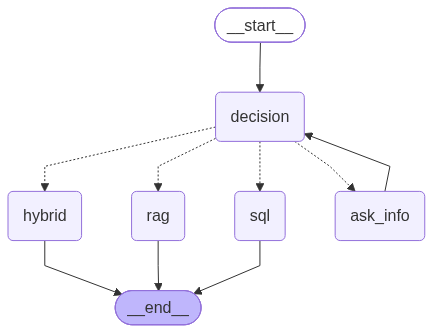

In [84]:
from IPython.display import display, Image

graph_bytes = grafo.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

In [72]:
r = grafo.invoke({'question':'tienen cursos de python y cual es su precio y como los podria rembolsar?'})

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
r

In [ ]:
print(r['answer'])

In [94]:
config = {
    "configurable": {
        "thread_id": "5"
    }
}

result = grafo.invoke(
    {
        "question": "¿Cuánto cuesta?"
    },
    config=config
)

Decidiendo el flujo después del nodo 'triaje'...


In [91]:
result

{'question': '¿Cuánto cuesta?',
 'decision': {'route': 'ask_info'},
 '__interrupt__': [Interrupt(value='¿A qué curso se refiere?', id='8ab6478264ccebc1a1a4b7dbafd691f2')]}

In [95]:
from langgraph.types import Command
result = grafo.invoke(
    Command(resume="sobre los cursos de python o java"),
    config=config
)

Decidiendo el flujo después del nodo 'triaje'...


In [96]:
print(result['answer'])

Los cursos relacionados con Python y Java tienen los siguientes precios:

* **Análisis y Visualización de Datos con Python:** 119.99
* **Desarrollo Web con HTML, CSS y JavaScript:** 69.99
* **Python desde Cero:** 59.99
* **Python Intermedio: POO y Buenas Prácticas:** 99.99
* **Automatización con Python:** 89.99
* **Java desde Cero:** 64.99
* **Java Enterprise con Spring Boot:** 179.99
